# 0.0 Import

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import recall_score, precision_score, f1_score
import joblib



# 0.1 Load dataset

In [26]:
df = pd.read_csv("../dataset/BankChurners.csv")

# 1.0. Descrição dos dados

## 1.1 Renomear Colunas

In [27]:
df.columns = df.columns.str.lower()

## 1.2 Dimensões

In [28]:
df.shape

(10127, 23)

## 1.3 Tipos dos dados

In [29]:
df.dtypes

clientnum                                                                                                                               int64
attrition_flag                                                                                                                            str
customer_age                                                                                                                            int64
gender                                                                                                                                    str
dependent_count                                                                                                                         int64
education_level                                                                                                                           str
marital_status                                                                                                                            str
income

## 1.4 Check NA

In [30]:
df.isna().sum()

clientnum                                                                                                                             0
attrition_flag                                                                                                                        0
customer_age                                                                                                                          0
gender                                                                                                                                0
dependent_count                                                                                                                       0
education_level                                                                                                                       0
marital_status                                                                                                                        0
income_category                                 

## 1.5 Remover colunas

In [31]:
df = df.drop(
    columns=[
        'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1',
        'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2'
    ]
)

## 1.6 Estatistica Descritiva

In [32]:
cat_attributes = df.select_dtypes(exclude=['int64', 'float64'])
num_attributes = df.select_dtypes(include=['int64', 'float64'])

### 1.6.1 Numericas

In [33]:
num_attributes.describe()

,clientnum,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


### 1.6.2 Categoricas

#### 1.6.2.1 Gender

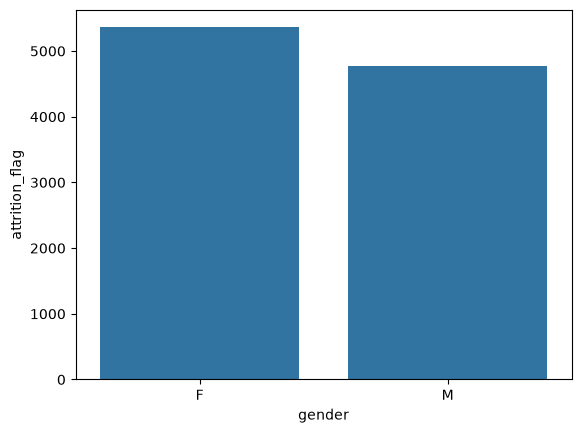

In [34]:
aux = cat_attributes[['gender','attrition_flag']].groupby('gender').count().reset_index()

sns.barplot(
    data=aux,
    x='gender',
    y='attrition_flag'
)

plt.show()

#### 1.6.2.2 Education Level

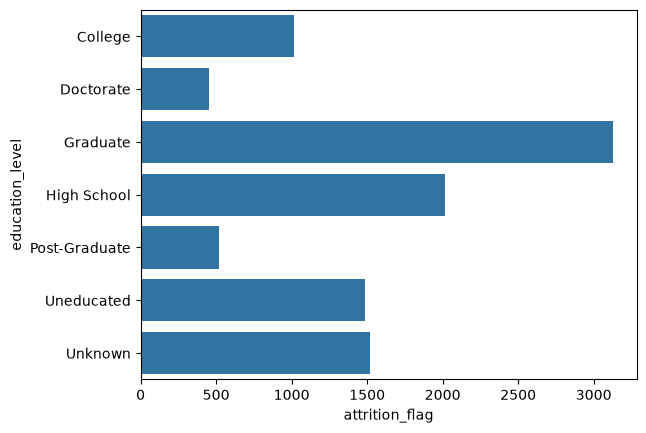

In [35]:
aux = cat_attributes[['education_level','attrition_flag']].groupby('education_level').count().reset_index()

sns.barplot(
    data=aux,
    x='attrition_flag',
    y='education_level'
)

plt.show()

#### 1.6.2.3 marital_status

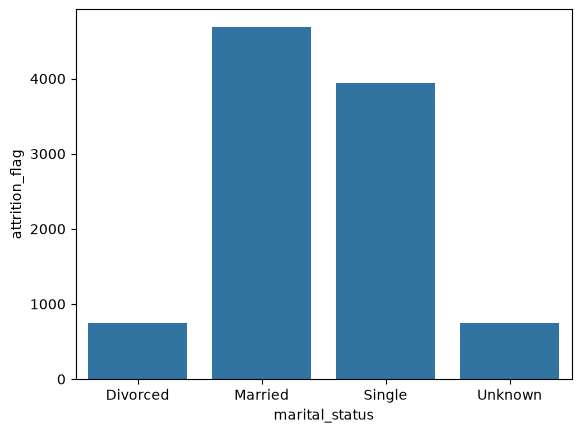

In [36]:
aux = cat_attributes[['marital_status','attrition_flag']].groupby('marital_status').count().reset_index()

sns.barplot(
    data=aux,
    x='marital_status',
    y='attrition_flag'
)

plt.show()

#### 1.6.2.4 income_category

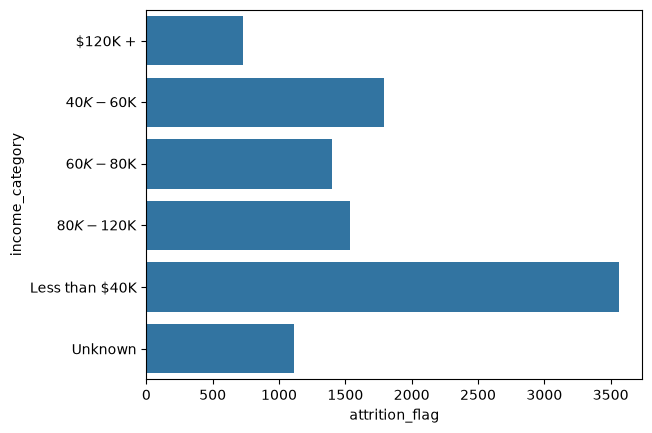

In [37]:
aux = cat_attributes[['income_category','attrition_flag']].groupby('income_category').count().reset_index()

sns.barplot(
    data=aux,
    x='attrition_flag',
    y='income_category'
)

plt.show()

#### 1.6.2.5 card_category

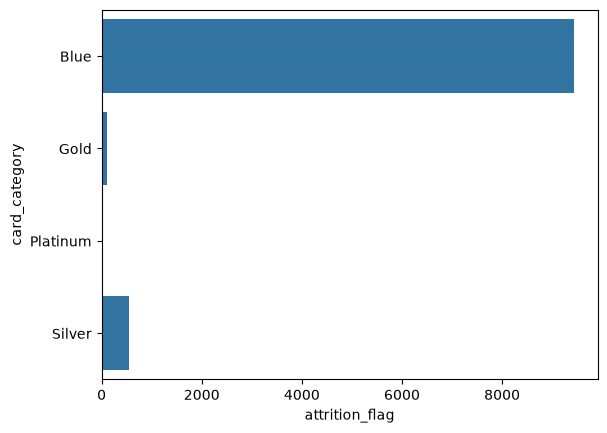

In [38]:
aux = cat_attributes[['card_category','attrition_flag']].groupby('card_category').count().reset_index()

sns.barplot(
    data=aux,
    x='attrition_flag',
    y='card_category'
)


plt.show()

# 2.0 Divisão entre treino e test

In [39]:
x = df.drop(columns=['clientnum', 'attrition_flag'])
y = df['attrition_flag']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
variaveis_numericas = x.select_dtypes(include=['int64', 'float64']).columns
variaveis_categoricas = x.select_dtypes(exclude=['int64', 'float64']).columns

# 3.0 Pre processamento

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), variaveis_numericas),
        ('cat', OneHotEncoder(), variaveis_categoricas)
    ],
    remainder='passthrough'
)

# 4.0 Machine Learning

In [43]:
df_result = pd.DataFrame()

In [44]:
x_train.columns

Index(['customer_age', 'gender', 'dependent_count', 'education_level',
       'marital_status', 'income_category', 'card_category', 'months_on_book',
       'total_relationship_count', 'months_inactive_12_mon',
       'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
       'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt',
       'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio'],
      dtype='str')

In [45]:
y_train

9066    Existing Customer
5814    Attrited Customer
792     Existing Customer
1791    Existing Customer
5011    Existing Customer
              ...        
5734    Attrited Customer
5191    Attrited Customer
5390    Existing Customer
860     Existing Customer
7270    Existing Customer
Name: attrition_flag, Length: 8101, dtype: str

## 4.1 Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', dt)
])

param_grid= {
    'dt__max_depth': [None, 3, 5, 20],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3
)

grid_search.fit(x_train, y_train)

ypred = grid_search.predict(x_test)

recall = recall_score(y_test, ypred, average='weighted')
precision = precision_score(y_test, ypred, average='weighted')
f1 = f1_score(y_test, ypred, average='weighted')

resultado = pd.DataFrame({
    "modelo":['DecisionTree'],
    'recall':[recall],
    'precision': [precision],
    'f1': [f1]
})

df_result = pd.concat([df_result, resultado], ignore_index=True)


In [49]:
df_result

,modelo,recall,precision,f1
0,DecisionTree,0.941757,0.940771,0.941163
1,DecisionTree,0.941757,0.940771,0.941163


In [50]:
joblib.dump(grid_search.best_estimator_, '../modelo/churn.joblib')

['../modelo/churn.joblib']

In [51]:
grid_search.best_params_

{'dt__max_depth': None, 'dt__min_samples_leaf': 10, 'dt__min_samples_split': 2}

## 4.2 Logistic Regressor

In [52]:
lr = LogisticRegression(random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', lr)
])

param_grid = {
    'lr__C': [0.1, 1, 10],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__max_iter': [100, 150, 200]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3
)

grid_search.fit(x_train, y_train)

ypred = grid_search.predict(x_test)

recall = recall_score(y_test, ypred, average='weighted')
precision = precision_score(y_test, ypred, average='weighted')
f1 = f1_score(y_test, ypred, average='weighted')

resultado = pd.DataFrame({
    'modelo': ['LogisticRegressor'],
    'recall': [recall],
    'precision': [precision],
    'f1': [f1]
})

df_result = pd.concat([df_result, resultado], ignore_index=True)

In [53]:
df_result

,modelo,recall,precision,f1
0,DecisionTree,0.941757,0.940771,0.941163
1,DecisionTree,0.941757,0.940771,0.941163
2,LogisticRegressor,0.897335,0.889860,0.889914


In [54]:
joblib.dump(grid_search.best_estimator_, '../modelo/churn.joblib')

['../modelo/churn.joblib']

## 4.3 KNN

In [27]:
knn = KNeighborsClassifier()

pipeline = Pipeline([
    ('proprocessor', preprocessor),
    ('knn', knn)
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance'],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3
)

grid_search.fit(x_train, y_train)

ypred = grid_search.predict(x_test)

recall = recall_score(y_test, ypred, average='weighted')
precision = precision_score(y_test, ypred, average='weighted')
f1 = f1_score(y_test, ypred, average='weighted')

resultado = pd.DataFrame({
    'modelo': ['KNN'],
    'recall':[recall],
    'precision': [precision],
    'f1': [f1]
})

df_result = pd.concat([df_result, resultado])

In [28]:
df_result

,modelo,recall,precision,f1
0,DecisionTree,0.941757,0.940771,0.941163
1,LogisticRegressor,0.897335,0.889860,0.889914
0,KNN,0.844521,0.820307,0.825906
